# Sentiment analisys with RNN

GRU network for classifying whether given movie review is *positive* or *negative*. Network was trained on 50 000 IMDB movie reviews with total lengths between 4 and 2500 words. After 5 epochs classification accuracy is over 90%.

TODO: get more data and create confusion matrix

In [67]:
# imports
from keras.layers import GRU, Dense, Embedding, Input, Bidirectional, Dropout
from keras.models import Model
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from tensorflow.data import Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns

In [2]:
# load dataset
df = pd.read_csv('IMDB Dataset.csv', sep=',')

# convert both columns to numpy arrays
reviews = df['review'].tolist()
labels = df['sentiment'].tolist()
df.head(3)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


**********STATISTICS**********

max length:	2470
min length:	4
max sequence length:	 488
no. of sequences smaller than max_length:	 45845
no. of sequences greater than max_length:	 4155
no. of sequences in total:			 50000


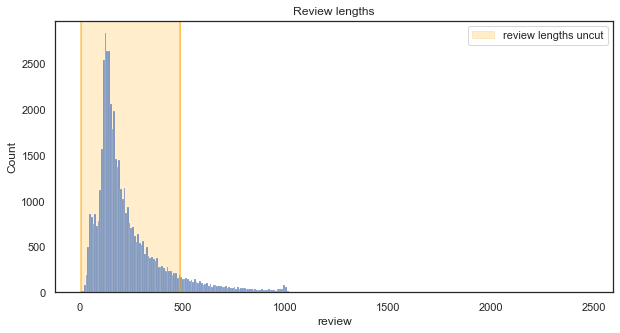

In [60]:
# get lengths of every review in dataset
seq_lengths = df.review.apply(lambda x: len(x.split()))

# calculate max length
max_length = int(np.mean(seq_lengths) + 1.5 * np.std(seq_lengths))
no_samples = len(seq_lengths)

# print some basic stats
print('**********STATISTICS**********\n')
print(f'max length:\t{seq_lengths.max()}\nmin length:\t{seq_lengths.min()}')
print('max sequence length:\t', max_length)
print('no. of sequences smaller than max_length:\t', np.sum(seq_lengths < max_length))
print('no. of sequences greater than max_length:\t', np.sum(seq_lengths >= max_length))
print('no. of sequences in total:\t\t\t', len(seq_lengths))

# display histogram of review lengths
plt.figure(figsize=(10,5))
plt.title('Review lengths')
plt.axvline(seq_lengths.min(), color='orange', alpha=0.6)
plt.axvline(max_length, color='orange', alpha=0.6)
plt.axvspan(seq_lengths.min(), max_length, alpha=0.2, color='orange', label='review lengths uncut')
sns.histplot(seq_lengths)
plt.legend()
plt.show()

In [49]:
# initialize tokenizer
tokenizer = Tokenizer(num_words=10000,
                      filters='1234567890!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
                      oov_token='<unk>')
tokenizer.fit_on_texts(reviews)

In [50]:
# tokenize and pad sequences to max length
sequences = tokenizer.texts_to_sequences(reviews)
seqs_padded = pad_sequences(sequences, maxlen=max_length)

In [51]:
# convert labels to binary form
labels_binary = [1 if i == 'positive' else 0 for i in labels]

In [52]:
# function used to rename tensorflow dataset
def rename(x, y):
    return {'inputs': x}, y

In [53]:
# create tensorflow dataset
dataset = Dataset.from_tensor_slices((seqs_padded, labels_binary))
dataset = dataset.map(rename)
dataset = dataset.shuffle(10000).batch(32, drop_remainder=True)

In [54]:
# split dataset for training and validation
size = 0.8
split = int(size*len(dataset))
train_set = dataset.take(split)
val_set = dataset.skip(split)

In [68]:
# GRU network configuration
hidden_dim = 64
gru1 = 64
gru2 = 64
vocab_size = 10000+1

In [69]:
# connect the network
inputs = Input(shape=(max_length, ), name='inputs')
embeddings = Embedding(input_dim=vocab_size, output_dim=hidden_dim)(inputs)
x = Bidirectional(GRU(units=gru1, return_sequences=True))(embeddings)
x = Bidirectional(GRU(units=gru2))(x)
# x = Dropout(0.5)(x)
out = Dense(units=1, activation='sigmoid')(x)

# build and compile the network 
model = Model(inputs=inputs, outputs=out)
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [70]:
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
inputs (InputLayer)          [(None, 488)]             0         
_________________________________________________________________
embedding (Embedding)        (None, 488, 64)           640064    
_________________________________________________________________
bidirectional (Bidirectional (None, 488, 128)          49920     
_________________________________________________________________
bidirectional_1 (Bidirection (None, 128)               74496     
_________________________________________________________________
dense (Dense)                (None, 1)                 129       
Total params: 764,609
Trainable params: 764,609
Non-trainable params: 0
_________________________________________________________________


In [109]:
# train the network
history = model.fit(train_set,
                   validation_data=val_set,
                   epochs=5)

Epoch 1/5
1249/1249 [==============================] - 397s 315ms/step - loss: 0.5027 - accuracy: 0.7351 - val_loss: 0.2240 - val_accuracy: 0.9123
Epoch 2/5
1249/1249 [==============================] - 384s 308ms/step - loss: 0.2274 - accuracy: 0.9114 - val_loss: 0.1736 - val_accuracy: 0.9368
Epoch 3/5
1249/1249 [==============================] - 379s 304ms/step - loss: 0.1554 - accuracy: 0.9416 - val_loss: 0.1514 - val_accuracy: 0.9448
Epoch 4/5
1249/1249 [==============================] - 394s 315ms/step - loss: 0.1078 - accuracy: 0.9621 - val_loss: 0.1371 - val_accuracy: 0.9544
Epoch 5/5
1249/1249 [==============================] - 386s 309ms/step - loss: 0.0756 - accuracy: 0.9754 - val_loss: 0.1369 - val_accuracy: 0.9541


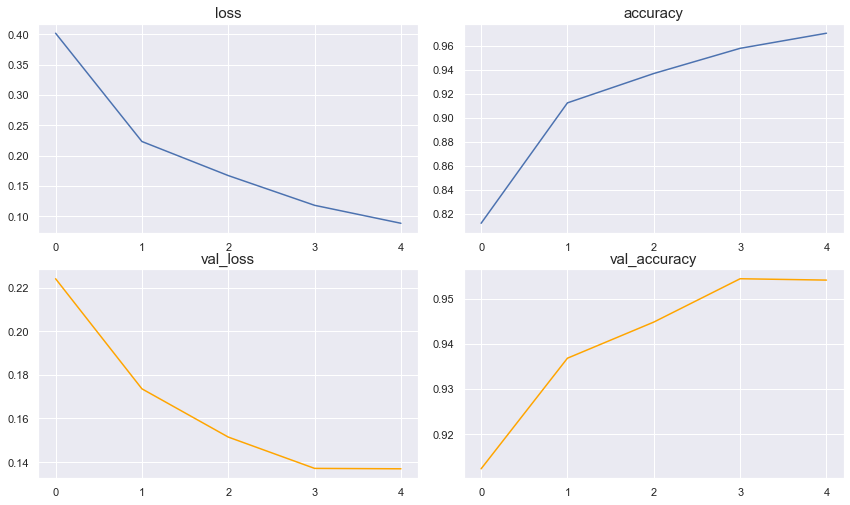

In [47]:
# display loss and accuracy during training phase
fig, axs = plt.subplots(2, 2, figsize=(12,7))
fig.tight_layout()

axs[0,0].xaxis.set_major_locator(MaxNLocator(integer=True))
axs[0,0].set_title('loss', fontsize=15)
axs[0,0].plot(history['loss'])

axs[0,1].xaxis.set_major_locator(MaxNLocator(integer=True))
axs[0,1].set_title('accuracy', fontsize=15)
axs[0,1].plot(history['accuracy'])

axs[1,0].xaxis.set_major_locator(MaxNLocator(integer=True))
axs[1,0].set_title('val_loss', fontsize=15)
axs[1,0].plot(history['val_loss'], color='orange')

axs[1,1].xaxis.set_major_locator(MaxNLocator(integer=True))
axs[1,1].set_title('val_accuracy', fontsize=15)
axs[1,1].plot(history['val_accuracy'], color='orange')

plt.show()